# Experimento: fuzzy no threshold e level set arterial

Este notebook compara o pipeline original com uma variante em que apenas o threshold do pre-processamento muda para fuzzy. Na etapa de segmentacao arterial, ele tambem testa uma refinacao opcional por level set usando a mascara bruta do region growing como inicializacao.

As saidas foram separadas por etapa para facilitar a leitura: carregamento, threshold, deteccao dos ostios, segmentacao arterial e resumo final.


## 1. Ambiente

Configura o caminho do repositorio e importa as funcoes usadas no experimento.

In [1]:
# ruff: noqa: E402
import sys
from pathlib import Path

NOTEBOOK_CWD = Path.cwd().resolve()
for candidate in (NOTEBOOK_CWD, NOTEBOOK_CWD.parent, NOTEBOOK_CWD.parent.parent):
    src_dir = candidate / "src"
    if src_dir.exists():
        if str(src_dir) not in sys.path:
            sys.path.insert(0, str(src_dir))
        break

from utils.notebook_env import configure_notebook_environment  # noqa: E402

REPO_ROOT = configure_notebook_environment()


In [2]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.morphology import ball
from skimage.segmentation import (
    inverse_gaussian_gradient,
    morphological_geodesic_active_contour,
)

from utils.config_utils import scale_config_to_resolution
from utils.notebook_env import resolve_imagecas_base_path
from utils.config_utils import load_config_json
from utils.utils import dice_score
from utils.utils.nifti_io import load_raw_img_and_label
from utils.processing import (
    binary_closing,
    binary_dilation,
    downscale_image_ndi,
    run_core_preprocessing_pipeline,
    threshold_image_with_offset,
)
from utils.segmentation import (
    build_lcc_image_from_mask,
    detect_and_evaluate_ostia,
    fuzzy_trapezoid_threshold,
    get_or_compute_vesselness,
    get_or_detect_aorta_circles,
    get_or_segment_aorta,
    region_growing_segmentation,
)


## 2. Parametros do teste

Altere apenas esta celula para trocar a imagem, o fator de reducao ou a configuracao fuzzy. O cache fica desligado para evitar que resultados antigos influenciem a comparacao.

In [3]:
CONFIG_PATH = REPO_ROOT / "config/pipeline_config.json"
BASE_PATH = resolve_imagecas_base_path()

IMG_ID = 458
DOWNSCALE_FACTORS = (2, 2, 1)
MIN_HU = -300

FUZZY_MARGIN_HU = 80
FUZZY_ALPHA_CUT = 0.50

ARTERY_LEVEL_SET_CONFIG = {
    "num_iter": 25,
    "smoothing": 1,
    "balloon": 1,
    "threshold": "auto",
    "alpha": 1000,
    "sigma": 1.0,
    "roi_margin": 8,
}

SAVE_CSV_OUTPUTS = True
CSV_PREFIX = REPO_ROOT / "output/tmp_fuzzy_threshold_only"

CONFIG = load_config_json(str(CONFIG_PATH), {})
CONFIG["DOWNSCALE_FACTORS"] = list(DOWNSCALE_FACTORS)
CONFIG["LOAD_CACHE"] = False
CONFIG["SAVE_CACHE"] = False
RUN_CONFIG = scale_config_to_resolution(copy.deepcopy(CONFIG))
RUN_CONFIG["ARTERY_LEVEL_SET"] = ARTERY_LEVEL_SET_CONFIG

MAX_THRESHOLD_PERCENTILE = CONFIG.get("MAX_THRESHOLD_PERCENTILE", 99.7)

img_path = BASE_PATH / f"{IMG_ID}.img.nii.gz"
label_path = BASE_PATH / f"{IMG_ID}.label.nii.gz"

config_df = pd.DataFrame(
    [
        {
            "IMG_ID": IMG_ID,
            "base_path": str(BASE_PATH),
            "downscale_factors": DOWNSCALE_FACTORS,
            "max_threshold_percentile": MAX_THRESHOLD_PERCENTILE,
            "fuzzy_margin_hu": FUZZY_MARGIN_HU,
            "fuzzy_alpha_cut": FUZZY_ALPHA_CUT,
            "artery_level_set": ARTERY_LEVEL_SET_CONFIG,
            "load_cache": RUN_CONFIG["LOAD_CACHE"],
            "save_cache": RUN_CONFIG["SAVE_CACHE"],
        }
    ]
)
config_df


,IMG_ID,base_path,downscale_factors,max_threshold_percentile,fuzzy_margin_hu,fuzzy_alpha_cut,artery_level_set,load_cache,save_cache
0,458,/media/matheus/HD/DatasetsCCTA/ImageCAS/1-1000,"(2, 2, 1)",99.7,80,0.5,"{'num_iter': 25, 'smoothing': 1, 'balloon': 1,...",False,False


## 3. Funcoes auxiliares

A funcao fuzzy gera um mapa de pertinencia entre 0 e 1. O `alpha-cut` transforma esse mapa em mascara binaria para manter o restante do pipeline igual ao original.

In [4]:
def csv_path(step_name: str) -> Path:
    return CSV_PREFIX.with_name(f"{CSV_PREFIX.name}_{step_name}.csv")


def maybe_save_csv(df: pd.DataFrame, step_name: str) -> Path | None:
    if not SAVE_CSV_OUTPUTS:
        return None
    path = csv_path(step_name)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    return path


In [5]:
def run_detection_stage(
    variant_name: str,
    lcc_image: np.ndarray,
    label: np.ndarray,
    scaled_spacing: tuple[float, float, float],
    config: dict,
) -> dict:
    """Executa aorta + ostios. Nao cria cache quando SAVE_CACHE=False."""
    stage_root = REPO_ROOT / "output" / "tmp_fuzzy_threshold_only_no_cache"

    result = {
        "variant": variant_name,
        "ostia_found": False,
        "ostia_status": "not_evaluated",
        "both_correct": False,
        "both_tolerable": False,
        "left_dist_mm": np.inf,
        "right_dist_mm": np.inf,
        "left_intersects": False,
        "right_intersects": False,
        "ostia_left": None,
        "ostia_right": None,
        "num_circles": 0,
        "aorta_voxels": 0,
        "ostia_error": None,
        "error": None,
    }

    vesselness_ostios = get_or_compute_vesselness(
        str(IMG_ID),
        lcc_image,
        cache_dir=str(stage_root / variant_name / "vesselness_ostios_cache"),
        vesselness_config=config["VESSELNESS_AORTA"],
        load_cache=config["LOAD_CACHE"],
        save_cache=config["SAVE_CACHE"],
        use_gpu=config.get("USE_GPU", False),
    )

    detected_circles = get_or_detect_aorta_circles(
        str(IMG_ID),
        lcc_image,
        DOWNSCALE_FACTORS,
        scaled_spacing,
        config["CIRCLE_DETECTION"],
        stage_root / variant_name,
        load_cache=config["LOAD_CACHE"],
        save_cache=config["SAVE_CACHE"],
    )
    result["num_circles"] = len(detected_circles)

    aorta_mask = get_or_segment_aorta(
        str(IMG_ID),
        lcc_image,
        detected_circles,
        config["LEVEL_SET"],
        stage_root / variant_name,
        load_cache=config["LOAD_CACHE"],
        save_cache=config["SAVE_CACHE"],
        use_gpu=config.get("USE_GPU", False),
    )
    result["aorta_voxels"] = int(aorta_mask.sum())

    try:
        ostia_eval = detect_and_evaluate_ostia(
            aorta_mask,
            vesselness_ostios,
            label,
            scaled_spacing,
            config,
        )
    except ValueError as exc:
        result["ostia_status"] = "not_found"
        result["ostia_error"] = str(exc)
        return result

    if ostia_eval["both_correct"]:
        ostia_status = "both_correct"
    elif ostia_eval["both_tolerable"]:
        ostia_status = "both_tolerable"
    else:
        ostia_status = "found_but_wrong"

    result.update(
        {
            "ostia_found": True,
            "ostia_status": ostia_status,
            "both_correct": bool(ostia_eval["both_correct"]),
            "both_tolerable": bool(ostia_eval["both_tolerable"]),
            "left_dist_mm": ostia_eval["left_info"]["physical_dist"],
            "right_dist_mm": ostia_eval["right_info"]["physical_dist"],
            "left_intersects": ostia_eval["left_info"]["intersects"],
            "right_intersects": ostia_eval["right_info"]["intersects"],
            "ostia_left": tuple(map(int, ostia_eval["ostia_left"])),
            "ostia_right": tuple(map(int, ostia_eval["ostia_right"])),
            "label_artery": ostia_eval["label_artery"],
            "aorta_mask": aorta_mask,
            "vesselness_ostios": vesselness_ostios,
        }
    )
    return result


def postprocess_artery_mask(mask: np.ndarray, config: dict) -> np.ndarray:
    """Aplica apenas o pos-processamento morfologico usado no pipeline."""
    post_config = config["POSTPROCESSING"]
    closed_mask = binary_closing(
        mask > 0,
        structure=ball(post_config["closing_radius"]),
        gpu=config.get("USE_GPU", False),
    )
    return binary_dilation(
        closed_mask,
        structure=ball(post_config["dilation_radius"]),
        gpu=config.get("USE_GPU", False),
    )


def refine_artery_with_level_set(
    guide_image: np.ndarray,
    initial_mask: np.ndarray,
    level_set_config: dict,
) -> np.ndarray:
    """Refina a mascara bruta da arteria com MGAC usando uma ROI ao redor dela."""
    initial_mask = initial_mask > 0
    if not initial_mask.any():
        return np.zeros_like(initial_mask, dtype=np.uint8)

    coords = np.argwhere(initial_mask)
    margin = int(level_set_config.get("roi_margin", 8))
    mins = np.maximum(coords.min(axis=0) - margin, 0)
    maxs = np.minimum(coords.max(axis=0) + margin + 1, guide_image.shape)
    roi = tuple(slice(int(mins[axis]), int(maxs[axis])) for axis in range(3))

    work_image = guide_image[roi].astype(np.float32)
    work_init = initial_mask[roi].astype(np.int8)
    if not work_init.any():
        return np.zeros_like(initial_mask, dtype=np.uint8)

    edge_image = inverse_gaussian_gradient(
        work_image,
        alpha=level_set_config.get("alpha", 1000),
        sigma=level_set_config.get("sigma", 1.0),
    )
    refined_roi = morphological_geodesic_active_contour(
        edge_image,
        num_iter=level_set_config.get("num_iter", 25),
        init_level_set=work_init,
        smoothing=level_set_config.get("smoothing", 1),
        balloon=level_set_config.get("balloon", 1),
        threshold=level_set_config.get("threshold", "auto"),
    )

    refined_mask = np.zeros_like(initial_mask, dtype=np.uint8)
    refined_mask[roi] = refined_roi.astype(np.uint8)
    return refined_mask


def build_segmentation_case_rows(result: dict) -> list[dict]:
    """Transforma os Dices da segmentacao em linhas comparaveis."""
    variant = result["variant"]
    uses_fuzzy = variant == "fuzzy_threshold_only"
    case_specs = [
        (
            "region_growing_raw",
            False,
            False,
            result.get("dice_without_level_set_without_morphology", np.nan),
            result.get("raw_artery_voxels", 0),
        ),
        (
            "region_growing_with_morphology",
            False,
            True,
            result.get("dice_without_level_set_with_morphology", np.nan),
            result.get("morphology_artery_voxels", 0),
        ),
        (
            "level_set_raw",
            True,
            False,
            result.get("dice_with_level_set_without_morphology", np.nan),
            result.get("level_set_artery_voxels", 0),
        ),
        (
            "level_set_with_morphology",
            True,
            True,
            result.get("dice_with_level_set_with_morphology", np.nan),
            result.get("level_set_morphology_artery_voxels", 0),
        ),
    ]
    return [
        {
            "variant": variant,
            "threshold_label": "fuzzy" if uses_fuzzy else "crisp",
            "uses_fuzzy_threshold": uses_fuzzy,
            "segmentation_case": case_name,
            "uses_level_set": uses_level_set,
            "uses_morphology": uses_morphology,
            "dice_artery": dice,
            "artery_voxels": int(voxels) if pd.notna(voxels) else 0,
            "segmentation_attempted": result["segmentation_attempted"],
            "proceeded_with_bad_ostia": result["proceeded_with_bad_ostia"],
            "segmentation_error": result["segmentation_error"],
        }
        for case_name, uses_level_set, uses_morphology, dice, voxels in case_specs
    ]


def run_segmentation_stage(
    detection_result: dict,
    lcc_image: np.ndarray,
    config: dict,
) -> dict:
    """Roda region growing, level set arterial e morfologia para comparar Dices."""
    result = {
        "variant": detection_result["variant"],
        "segmentation_attempted": False,
        "proceeded_with_bad_ostia": False,
        "dice_artery": np.nan,
        "artery_voxels": 0,
        "raw_artery_voxels": 0,
        "level_set_artery_voxels": 0,
        "morphology_artery_voxels": 0,
        "level_set_morphology_artery_voxels": 0,
        "dice_without_level_set_without_morphology": np.nan,
        "dice_without_level_set_with_morphology": np.nan,
        "dice_with_level_set_without_morphology": np.nan,
        "dice_with_level_set_with_morphology": np.nan,
        "best_segmentation_case": None,
        "best_dice_artery": np.nan,
        "segmentation_error": None,
    }

    if not detection_result["ostia_found"]:
        result["segmentation_error"] = detection_result["ostia_error"]
        result["case_rows"] = build_segmentation_case_rows(result)
        return result

    result["segmentation_attempted"] = True
    result["proceeded_with_bad_ostia"] = not (
        detection_result["both_correct"] or detection_result["both_tolerable"]
    )

    stage_root = REPO_ROOT / "output" / "tmp_fuzzy_threshold_only_no_cache"
    vesselness_artery = get_or_compute_vesselness(
        str(IMG_ID),
        lcc_image,
        cache_dir=str(stage_root / detection_result["variant"] / "vesselness_artery_cache"),
        vesselness_config=config["VESSELNESS_ARTERY"],
        load_cache=config["LOAD_CACHE"],
        save_cache=config["SAVE_CACHE"],
        use_gpu=config.get("USE_GPU", False),
    )

    rg_config = config["REGION_GROWING"]
    region_growing_params = {
        "threshold": (vesselness_artery.max() - vesselness_artery.min())
        / rg_config["threshold_divisor"],
        "max_volume": rg_config["max_volume"],
        "min_vesselness": vesselness_artery.max()
        * rg_config["min_vesselness_fraction"],
        "relaxed_floor_factor": rg_config["relaxed_floor_factor"],
        "switch_at_voxels": rg_config["switch_at_voxels"],
        "comparison_window": rg_config["comparison_window"],
        "smooth_relaxation": rg_config["smooth_relaxation"],
        "verbose": False,
    }

    left_mask = region_growing_segmentation(
        vesselness_artery,
        seed_point=detection_result["ostia_left"],
        **region_growing_params,
    )
    right_mask = region_growing_segmentation(
        vesselness_artery,
        seed_point=detection_result["ostia_right"],
        **region_growing_params,
    )
    raw_artery_mask = ((left_mask > 0) | (right_mask > 0)).astype(np.uint8)
    level_set_artery_mask = refine_artery_with_level_set(
        vesselness_artery,
        raw_artery_mask,
        config["ARTERY_LEVEL_SET"],
    )
    morphology_artery_mask = postprocess_artery_mask(raw_artery_mask, config)
    level_set_morphology_artery_mask = postprocess_artery_mask(
        level_set_artery_mask,
        config,
    )

    label_artery = detection_result["label_artery"]
    result.update(
        {
            "raw_artery_voxels": int(raw_artery_mask.sum()),
            "level_set_artery_voxels": int(level_set_artery_mask.sum()),
            "morphology_artery_voxels": int(morphology_artery_mask.sum()),
            "level_set_morphology_artery_voxels": int(
                level_set_morphology_artery_mask.sum()
            ),
            "dice_without_level_set_without_morphology": float(
                dice_score(raw_artery_mask, label_artery)
            ),
            "dice_without_level_set_with_morphology": float(
                dice_score(morphology_artery_mask, label_artery)
            ),
            "dice_with_level_set_without_morphology": float(
                dice_score(level_set_artery_mask, label_artery)
            ),
            "dice_with_level_set_with_morphology": float(
                dice_score(level_set_morphology_artery_mask, label_artery)
            ),
        }
    )

    # Mantem dice_artery como o resultado equivalente ao pipeline atual:
    # region growing seguido de pos-processamento morfologico, sem level set arterial.
    result["dice_artery"] = result["dice_without_level_set_with_morphology"]
    result["artery_voxels"] = result["morphology_artery_voxels"]

    dice_columns = {
        "region_growing_raw": result["dice_without_level_set_without_morphology"],
        "region_growing_with_morphology": result[
            "dice_without_level_set_with_morphology"
        ],
        "level_set_raw": result["dice_with_level_set_without_morphology"],
        "level_set_with_morphology": result["dice_with_level_set_with_morphology"],
    }
    result["best_segmentation_case"] = max(dice_columns, key=dice_columns.get)
    result["best_dice_artery"] = dice_columns[result["best_segmentation_case"]]
    result["case_rows"] = build_segmentation_case_rows(result)
    return result


## 4. Carregamento e reducao da imagem

Esta etapa carrega imagem/label, aplica o downsample na label e registra o espacamento usado nas metricas em milimetros.

In [6]:
nii_img, nii_label = load_raw_img_and_label(str(img_path), str(label_path))
image = nii_img.get_fdata(dtype=np.float32)
label = nii_label.get_fdata(dtype=np.float32).astype(np.uint8)
spacing = tuple(float(value) for value in nii_img.header.get_zooms()[:3])

down_label = downscale_image_ndi(
    label,
    DOWNSCALE_FACTORS,
    order=0,
).astype(np.uint8)
scaled_spacing = tuple(
    spacing[idx] * DOWNSCALE_FACTORS[idx] for idx in range(len(DOWNSCALE_FACTORS))
)

sample_info_df = pd.DataFrame(
    [
        {
            "IMG_ID": IMG_ID,
            "image_shape": image.shape,
            "label_shape": label.shape,
            "down_label_shape": down_label.shape,
            "spacing_mm": spacing,
            "scaled_spacing_mm": scaled_spacing,
        }
    ]
)
maybe_save_csv(sample_info_df, "sample_info")
sample_info_df


,IMG_ID,image_shape,label_shape,down_label_shape,spacing_mm,scaled_spacing_mm
0,458,"(512, 512, 275)","(512, 512, 275)","(256, 256, 275)","(0.3671875, 0.3671875, 0.5)","(0.734375, 0.734375, 0.5)"


## 5. Threshold

Aqui ficam apenas as saidas do pre-processamento. A linha `baseline_original_threshold` usa o threshold crisp original. A linha `fuzzy_threshold_only` usa a mesma faixa central, mas expande a borda pela pertinencia fuzzy e pelo `alpha-cut`.

In [7]:
down_image, _, baseline_lcc_image, baseline_threshold_values = run_core_preprocessing_pipeline(
    image,
    downscale_factors=DOWNSCALE_FACTORS,
    min_threshold=MIN_HU,
    max_threshold_percentile=MAX_THRESHOLD_PERCENTILE,
    lcc_per_slice=True,
    order=3,
    use_opencv=False,
)

max_hu = float(baseline_threshold_values[1])
fuzzy_membership = fuzzy_trapezoid_threshold(
    down_image,
    min_hu=MIN_HU,
    max_hu=max_hu,
    margin_hu=FUZZY_MARGIN_HU,
)
fuzzy_mask = fuzzy_membership >= FUZZY_ALPHA_CUT
fuzzy_effective_min_hu = MIN_HU - FUZZY_MARGIN_HU * (1 - FUZZY_ALPHA_CUT)
fuzzy_effective_max_hu = max_hu + FUZZY_MARGIN_HU * (1 - FUZZY_ALPHA_CUT)
fuzzy_lcc_image, fuzzy_lcc_mask = build_lcc_image_from_mask(
    down_image,
    fuzzy_mask,
    offset=abs(MIN_HU),
    per_slice=True,
)

_, baseline_mask, _ = threshold_image_with_offset(
    down_image,
    min_val=MIN_HU,
    max_val=int(max_hu),
)
_, baseline_lcc_mask = build_lcc_image_from_mask(
    down_image,
    baseline_mask,
    offset=abs(MIN_HU),
    per_slice=True,
)

threshold_df = pd.DataFrame(
    [
        {
            "variant": "baseline_original_threshold",
            "threshold_mode": "crisp",
            "core_min_hu": MIN_HU,
            "core_max_hu": max_hu,
            "effective_min_hu": MIN_HU,
            "effective_max_hu": max_hu,
            "fuzzy_margin_hu": np.nan,
            "fuzzy_alpha_cut": np.nan,
            "threshold_voxels": int(baseline_mask.sum()),
            "lcc_voxels": int(baseline_lcc_mask.sum()),
        },
        {
            "variant": "fuzzy_threshold_only",
            "threshold_mode": "fuzzy_alpha_cut",
            "core_min_hu": MIN_HU,
            "core_max_hu": max_hu,
            "effective_min_hu": fuzzy_effective_min_hu,
            "effective_max_hu": fuzzy_effective_max_hu,
            "fuzzy_margin_hu": FUZZY_MARGIN_HU,
            "fuzzy_alpha_cut": FUZZY_ALPHA_CUT,
            "threshold_voxels": int(fuzzy_mask.sum()),
            "lcc_voxels": int(fuzzy_lcc_mask.sum()),
        },
    ]
)
maybe_save_csv(threshold_df, "threshold")
threshold_df


,variant,threshold_mode,core_min_hu,core_max_hu,effective_min_hu,effective_max_hu,fuzzy_margin_hu,fuzzy_alpha_cut,threshold_voxels,lcc_voxels
0,baseline_original_threshold,crisp,-300,629.0,-300.0,629.0,NaN,NaN,11153120,10843087
1,fuzzy_threshold_only,fuzzy_alpha_cut,-300,629.0,-340.0,669.0,80.0,0.5,11233157,10918972


## 6. Deteccao da aorta e dos ostios

Esta etapa mostra apenas o que vem antes da segmentacao arterial: circulos detectados, tamanho da mascara da aorta, status dos ostios e distancias ate a label.

In [8]:
variant_inputs = {
    "baseline_original_threshold": baseline_lcc_image,
    "fuzzy_threshold_only": fuzzy_lcc_image,
}

detection_results = {
    variant: run_detection_stage(
        variant,
        lcc_image,
        down_label,
        scaled_spacing,
        RUN_CONFIG,
    )
    for variant, lcc_image in variant_inputs.items()
}

ostia_df = pd.DataFrame(
    [
        {
            "variant": result["variant"],
            "ostia_status": result["ostia_status"],
            "ostia_found": result["ostia_found"],
            "both_correct": result["both_correct"],
            "both_tolerable": result["both_tolerable"],
            "left_dist_mm": result["left_dist_mm"],
            "right_dist_mm": result["right_dist_mm"],
            "ostia_left": result["ostia_left"],
            "ostia_right": result["ostia_right"],
            "num_circles": result["num_circles"],
            "aorta_voxels": result["aorta_voxels"],
            "ostia_error": result["ostia_error"],
        }
        for result in detection_results.values()
    ]
)
maybe_save_csv(ostia_df, "ostia_detection")
ostia_df


Parada na fatia 109: Δr=4.50 ou dist=37.58
Parada na fatia 109: Δr=4.50 ou dist=37.58


,variant,ostia_status,ostia_found,both_correct,both_tolerable,left_dist_mm,right_dist_mm,ostia_left,ostia_right,num_circles,aorta_voxels,ostia_error
0,baseline_original_threshold,both_tolerable,True,False,True,0.734375,1.441740,"(91, 144, 115)","(99, 103, 169)",165,433211,None
1,fuzzy_threshold_only,both_tolerable,True,False,True,0.734375,1.152655,"(91, 144, 115)","(100, 102, 168)",165,434199,None


## 7. Segmentacao arterial

Esta etapa roda a segmentacao arterial a partir dos ostios encontrados e compara quatro saidas: region growing bruto, region growing com morfologia, region growing refinado por level set e level set com morfologia. O level set usa a mascara bruta do region growing como inicializacao.


In [9]:
segmentation_results = {
    variant: run_segmentation_stage(
        detection_result,
        variant_inputs[variant],
        RUN_CONFIG,
    )
    for variant, detection_result in detection_results.items()
}

segmentation_df = pd.DataFrame(
    [
        {key: value for key, value in result.items() if key != "case_rows"}
        for result in segmentation_results.values()
    ]
)
segmentation_comparison_df = pd.DataFrame(
    row
    for result in segmentation_results.values()
    for row in result["case_rows"]
)

maybe_save_csv(segmentation_comparison_df, "segmentation")
maybe_save_csv(segmentation_df, "segmentation_wide")
segmentation_comparison_df


,variant,threshold_label,uses_fuzzy_threshold,segmentation_case,uses_level_set,uses_morphology,dice_artery,artery_voxels,segmentation_attempted,proceeded_with_bad_ostia,segmentation_error
0,baseline_original_threshold,crisp,False,region_growing_raw,False,False,0.414568,11851,True,False,None
1,baseline_original_threshold,crisp,False,region_growing_with_morphology,False,True,0.776594,42286,True,False,None
2,baseline_original_threshold,crisp,False,level_set_raw,True,False,0.080211,1844,True,False,None
3,baseline_original_threshold,crisp,False,level_set_with_morphology,True,True,0.237289,5981,True,False,None
4,fuzzy_threshold_only,fuzzy,True,region_growing_raw,False,False,0.407402,11579,True,False,None
5,fuzzy_threshold_only,fuzzy,True,region_growing_with_morphology,False,True,0.780509,41750,True,False,None
6,fuzzy_threshold_only,fuzzy,True,level_set_raw,True,False,0.066883,1527,True,False,None
7,fuzzy_threshold_only,fuzzy,True,level_set_with_morphology,True,True,0.190578,4664,True,False,None


## 8. Resumo final

Resumo compacto com threshold, status dos ostios e os principais Dice da segmentacao arterial. `dice_artery` continua representando o resultado equivalente ao pipeline atual: region growing com pos-processamento morfologico e sem level set arterial.


In [10]:
summary_df = (
    threshold_df[
        [
            "variant",
            "threshold_mode",
            "effective_min_hu",
            "effective_max_hu",
            "threshold_voxels",
            "lcc_voxels",
        ]
    ]
    .merge(
        ostia_df[
            [
                "variant",
                "ostia_status",
                "both_correct",
                "both_tolerable",
                "left_dist_mm",
                "right_dist_mm",
                "num_circles",
                "aorta_voxels",
            ]
        ],
        on="variant",
    )
    .merge(
        segmentation_df[
            [
                "variant",
                "segmentation_attempted",
                "dice_without_level_set_without_morphology",
                "dice_without_level_set_with_morphology",
                "dice_with_level_set_without_morphology",
                "dice_with_level_set_with_morphology",
                "dice_artery",
                "best_segmentation_case",
                "best_dice_artery",
                "raw_artery_voxels",
                "morphology_artery_voxels",
                "level_set_artery_voxels",
                "level_set_morphology_artery_voxels",
                "proceeded_with_bad_ostia",
            ]
        ],
        on="variant",
    )
)

maybe_save_csv(summary_df, "summary")
summary_df


,variant,threshold_mode,effective_min_hu,effective_max_hu,threshold_voxels,lcc_voxels,ostia_status,both_correct,both_tolerable,left_dist_mm,...,dice_with_level_set_without_morphology,dice_with_level_set_with_morphology,dice_artery,best_segmentation_case,best_dice_artery,raw_artery_voxels,morphology_artery_voxels,level_set_artery_voxels,level_set_morphology_artery_voxels,proceeded_with_bad_ostia
0,baseline_original_threshold,crisp,-300.0,629.0,11153120,10843087,both_tolerable,False,True,0.734375,...,0.080211,0.237289,0.776594,region_growing_with_morphology,0.776594,11851,42286,1844,5981,False
1,fuzzy_threshold_only,fuzzy_alpha_cut,-340.0,669.0,11233157,10918972,both_tolerable,False,True,0.734375,...,0.066883,0.190578,0.780509,region_growing_with_morphology,0.780509,11579,41750,1527,4664,False


## 9. Visualizacao do threshold

Figura focada no pre-processamento. Ela nao mistura as metricas de ostios ou segmentacao.

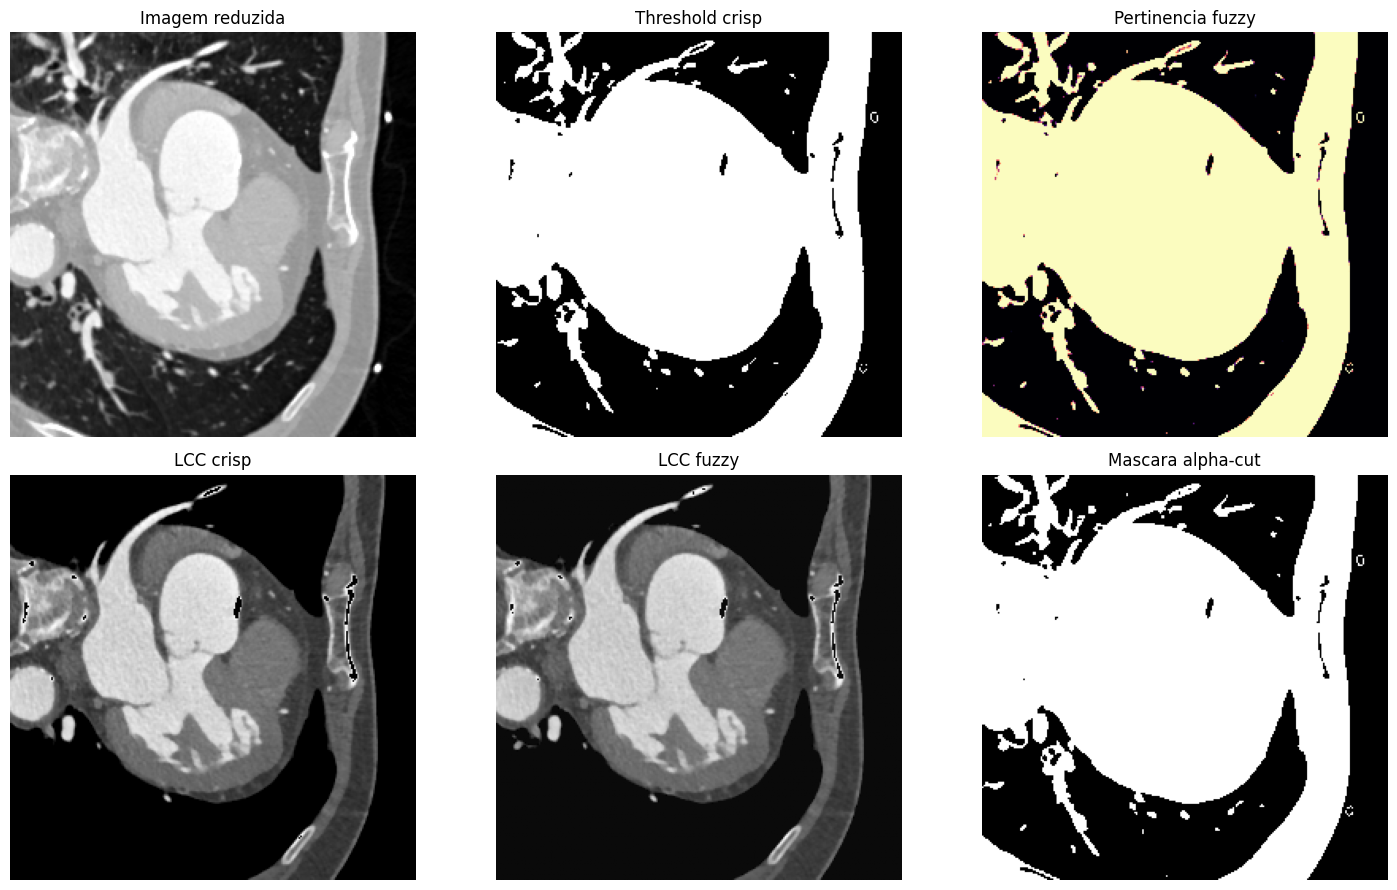

In [11]:
z_idx = down_image.shape[2] // 2
vmin, vmax = np.percentile(down_image[:, :, z_idx], [1, 99])

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].imshow(down_image[:, :, z_idx], cmap="gray", vmin=vmin, vmax=vmax)
axes[0, 0].set_title("Imagem reduzida")

axes[0, 1].imshow(baseline_mask[:, :, z_idx], cmap="gray")
axes[0, 1].set_title("Threshold crisp")

axes[0, 2].imshow(fuzzy_membership[:, :, z_idx], cmap="magma", vmin=0, vmax=1)
axes[0, 2].set_title("Pertinencia fuzzy")

axes[1, 0].imshow(baseline_lcc_image[:, :, z_idx], cmap="gray")
axes[1, 0].set_title("LCC crisp")

axes[1, 1].imshow(fuzzy_lcc_image[:, :, z_idx], cmap="gray")
axes[1, 1].set_title("LCC fuzzy")

axes[1, 2].imshow(fuzzy_mask[:, :, z_idx], cmap="gray")
axes[1, 2].set_title("Mascara alpha-cut")

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()
